# 0. Imports and definitions

In [214]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [143]:
def plot_series(df=None, columns=None, series=pd.Series([]),
                label=None, ylabel=None, title=None, start=0, end=None,
                marker='o', markersize=4, linestyle='-', figsize=(14, 6)):
    """
    Plots one or multiple time-series from a dataframe or a custom pandas series.
    'columns' accepts a single string or a list of strings.
    'label' accepts a single string or a list of strings matching the columns.
    'start' and 'end' accept both integer positions and UTC timestamp strings
    like '2015-01-05 11:00:00+00:00'.
    """
    def _slice(data):
        if isinstance(start, str) or isinstance(end, str):
            s = pd.Timestamp(start) if isinstance(start, str) else data.index[start]
            e = pd.Timestamp(end)   if isinstance(end, str)   else (data.index[end] if end is not None else data.index[-1])
            return data.loc[s:e]
        return data.iloc[start:end]

    # Normalize columns and labels to lists
    if isinstance(columns, str):
        columns = [columns]
    if isinstance(label, str):
        label = [label]
    if columns and label and len(label) != len(columns):
        raise ValueError(f"'label' length ({len(label)}) must match 'columns' length ({len(columns)})")

    sns.set()
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel('Date', fontsize=16)

    if columns is not None:
        alpha = 0.6 if len(columns) > 1 else 1.0
        for i, col in enumerate(columns):
            lbl = label[i] if label else col
            ax.plot(_slice(df[col]), marker=marker, linestyle=linestyle,
                    markersize=markersize, label=lbl, alpha=alpha)
        ax.set_ylabel(ylabel, fontsize=16)

    if series.any():
        lbl = label[0] if label else None
        ax.plot(_slice(series), marker=marker, linestyle=linestyle,
                markersize=markersize, label=lbl)
        ax.set_ylabel(ylabel, fontsize=16)

    ax.legend(fontsize=16)
    if title:
        ax.set_title(title, fontsize=24)

    ax.grid(True)
    plt.tight_layout()
    return ax

# 1. Exploration and Cleaning

In [144]:
df_energy = pd.read_csv('../data/raw/energy_dataset.csv')
df_weather = pd.read_csv('../data/raw/weather_features.csv')

## 1.1. Energy dataset

In [145]:
df_energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [146]:
# We set 'time' as time index with hourly frequency
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_energy.set_index('time', inplace=True)
df_energy = df_energy.resample('h').asfreq()
df_energy.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [147]:
df_energy.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.00,35046.00,35046.0,35046.00,35046.00,35045.00,35046.0,35046.0,35046.0,0.0,...,35045.00,35046.0,35046.00,35064.00,0.0,35064.00,35064.00,35028.00,35064.00,35064.00
mean,383.51,448.06,0.0,5622.74,4256.07,298.32,0.0,0.0,0.0,NaN,...,269.45,0.0,5464.48,1439.07,NaN,5471.22,28712.13,28696.94,49.87,57.88
std,85.35,354.57,0.0,2201.83,1961.60,52.52,0.0,0.0,0.0,NaN,...,50.20,0.0,3213.69,1677.70,NaN,3176.31,4594.10,4574.99,14.62,14.20
min,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,NaN,...,0.00,0.0,0.00,0.00,NaN,237.00,18105.00,18041.00,2.06,9.33
25%,333.00,0.00,0.0,4126.00,2527.00,263.00,0.0,0.0,0.0,NaN,...,240.00,0.0,2933.00,69.00,NaN,2979.00,24793.75,24807.75,41.49,49.35
50%,367.00,509.00,0.0,4969.00,4474.00,300.00,0.0,0.0,0.0,NaN,...,279.00,0.0,4849.00,576.00,NaN,4855.00,28906.00,28901.00,50.52,58.02
75%,433.00,757.00,0.0,6429.00,5838.75,330.00,0.0,0.0,0.0,NaN,...,310.00,0.0,7398.00,2636.00,NaN,7353.00,32263.25,32192.00,60.53,68.01
max,592.00,999.00,0.0,20034.00,8359.00,449.00,0.0,0.0,0.0,NaN,...,357.00,0.0,17436.00,5836.00,NaN,17430.00,41390.00,41015.00,101.99,116.80


In [148]:
# We find the columns that don't have values
cols_zero_or_nan = [
    col for col in df_energy.columns
    if df_energy[col].isna().all() or (df_energy[col].fillna(0) == 0).all()
]

print(cols_zero_or_nan)

['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation marine', 'generation wind offshore', 'forecast wind offshore eday ahead']


Columns composed entirely of zeros or NaN values will be removed, as they contain no usable information

In [149]:
# Drop useless columns
df_energy = df_energy.drop(cols_zero_or_nan, axis=1)
df_energy.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,35046.00,35046.00,35046.00,35045.00,35046.00,35064.00,35064.00,35064.00,35028.00,35064.00,35064.00
mean,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,60.23,85.64,1432.67,269.45,5464.48,1439.07,5471.22,28712.13,28696.94,49.87,57.88
std,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,20.24,14.08,1680.12,50.20,3213.69,1677.70,3176.31,4594.10,4574.99,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,237.00,18105.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,53.00,73.00,71.00,240.00,2933.00,69.00,2979.00,24793.75,24807.75,41.49,49.35
50%,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,57.00,88.00,616.00,279.00,4849.00,576.00,4855.00,28906.00,28901.00,50.52,58.02
75%,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,80.00,97.00,2578.00,310.00,7398.00,2636.00,7353.00,32263.25,32192.00,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,5836.00,17430.00,41390.00,41015.00,101.99,116.80


We also remove the forecasted variables and the variables that contain temporal leakage

In [150]:
# Drop forbidden variables
df_energy = df_energy.drop([
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'price day ahead',
    'price actual'
], axis=1)
df_energy.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load forecast,total load actual
count,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,35046.00,35046.00,35046.00,35045.00,35046.00,35064.00,35028.00
mean,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,60.23,85.64,1432.67,269.45,5464.48,28712.13,28696.94
std,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,20.24,14.08,1680.12,50.20,3213.69,4594.10,4574.99
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18105.00,18041.00
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,53.00,73.00,71.00,240.00,2933.00,24793.75,24807.75
50%,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,57.00,88.00,616.00,279.00,4849.00,28906.00,28901.00
75%,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,80.00,97.00,2578.00,310.00,7398.00,32263.25,32192.00
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41390.00,41015.00


In [151]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Freq: h
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil gas                        35046 non-null  float64
 3   generation fossil hard coal                  35046 non-null  float64
 4   generation fossil oil                        35045 non-null  float64
 5   generation hydro pumped storage consumption  35045 non-null  float64
 6   generation hydro run-of-river and poundage   35045 non-null  float64
 7   generation hydro water reservoir             35046 non-null  float64
 8   generation nuclear                           35047 non-null  float64
 9   generation other 

### 1.1.1 Outlier handling

In [152]:
(df_energy == 0).sum()

generation biomass                                 4
generation fossil brown coal/lignite           10517
generation fossil gas                              1
generation fossil hard coal                        3
generation fossil oil                              3
generation hydro pumped storage consumption    12607
generation hydro run-of-river and poundage         3
generation hydro water reservoir                   3
generation nuclear                                 3
generation other                                   4
generation other renewable                         3
generation solar                                   3
generation waste                                   3
generation wind onshore                            3
total load forecast                                0
total load actual                                  0
dtype: int64

`generation fossil brown coal/lignite` and `generation hydro pumped storage consumption` have too many zero values to be noise or outliers, but the rest of the variables have very few values. Let's check them.

In [154]:
few_zeros_cols = [col for col in df_energy.columns 
                  if 0 < (df_energy[col] == 0).sum() <= 10]

for col in few_zeros_cols:
    timestamps = df_energy.index[df_energy[col] == 0].tolist()
    print(f"\n{col} ({len(timestamps)} zeros):")
    for ts in timestamps:
        print(f"  {ts}")


generation biomass (4 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00
  2018-05-06 10:00:00+00:00

generation fossil gas (1 zeros):
  2018-06-02 09:00:00+00:00

generation fossil hard coal (3 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00

generation fossil oil (3 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00

generation hydro run-of-river and poundage (3 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00

generation hydro water reservoir (3 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00

generation nuclear (3 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00

generation other (4 zeros):
  2017-11-12 20:00:00+00:00
  2017-11-14 11:00:00+00:00
  2017-11-14 18:00:00+00:00
  2018-05-06 10:00:00+00:00

generation other renewable (

Most of those zeros share the same timestamp, so this must be due to data corruption or bad value imputation. We will set those values to NaN and handle them in the next section.

In [155]:
corrupt_timestamps = [
    '2017-11-12 20:00:00+00:00',
    '2017-11-14 11:00:00+00:00',
    '2017-11-14 18:00:00+00:00',
    '2018-05-06 10:00:00+00:00',
    '2018-06-02 09:00:00+00:00',
]

df_energy.loc[corrupt_timestamps] = df_energy.loc[corrupt_timestamps].replace(0, np.nan)

# Verify
print((df_energy == 0).sum()[few_zeros_cols])

generation biomass                            0
generation fossil gas                         0
generation fossil hard coal                   0
generation fossil oil                         0
generation hydro run-of-river and poundage    0
generation hydro water reservoir              0
generation nuclear                            0
generation other                              0
generation other renewable                    0
generation solar                              0
generation waste                              0
generation wind onshore                       0
dtype: int64


### 1.1.2 Missing values handling

In [156]:
# Find NaNs
print(f'Found {df_energy.isnull().values.sum()} missing values')
print(f'Found {df_energy.duplicated().values.sum()} duplicated values')

Found 335 missing values
Found 0 duplicated values


In [157]:
# Find the number of NaNs in each column
df_energy.isnull().sum(axis=0)

generation biomass                             23
generation fossil brown coal/lignite           21
generation fossil gas                          19
generation fossil hard coal                    21
generation fossil oil                          22
generation hydro pumped storage consumption    23
generation hydro run-of-river and poundage     22
generation hydro water reservoir               21
generation nuclear                             20
generation other                               22
generation other renewable                     21
generation solar                               21
generation waste                               22
generation wind onshore                        21
total load forecast                             0
total load actual                              36
dtype: int64

There are some NaNs, mostly on the target variable 'total load actual'. Let's have a look first of how long the missing value gaps are.

#### Target variable

In [158]:
df_energy[df_energy['total load actual'].isnull()]['total load actual']

time
2015-01-05 11:00:00+00:00   NaN
2015-01-05 12:00:00+00:00   NaN
2015-01-05 13:00:00+00:00   NaN
2015-01-05 14:00:00+00:00   NaN
2015-01-05 15:00:00+00:00   NaN
2015-01-05 16:00:00+00:00   NaN
2015-01-28 12:00:00+00:00   NaN
2015-02-01 06:00:00+00:00   NaN
2015-02-01 07:00:00+00:00   NaN
2015-02-01 08:00:00+00:00   NaN
2015-02-01 11:00:00+00:00   NaN
2015-02-01 12:00:00+00:00   NaN
2015-02-01 13:00:00+00:00   NaN
2015-02-01 14:00:00+00:00   NaN
2015-02-01 15:00:00+00:00   NaN
2015-02-01 16:00:00+00:00   NaN
2015-02-01 17:00:00+00:00   NaN
2015-02-01 18:00:00+00:00   NaN
2015-04-05 01:00:00+00:00   NaN
2015-04-16 07:00:00+00:00   NaN
2015-04-20 06:00:00+00:00   NaN
2015-04-23 19:00:00+00:00   NaN
2015-05-02 08:00:00+00:00   NaN
2015-05-29 01:00:00+00:00   NaN
2015-10-02 06:00:00+00:00   NaN
2015-10-02 09:00:00+00:00   NaN
2015-12-02 08:00:00+00:00   NaN
2016-04-25 03:00:00+00:00   NaN
2016-04-25 05:00:00+00:00   NaN
2016-05-10 21:00:00+00:00   NaN
2016-07-09 20:00:00+00:00   NaN
201

Most of the missing values are punctual hourly gaps, but there are two bigger gaps of a few hours. Let's plot those parts and see how they look like.

<Axes: title={'center': 'Actual Total Load - Missing values of 2015-01-05'}, xlabel='Date', ylabel='Total Load (MWh)'>

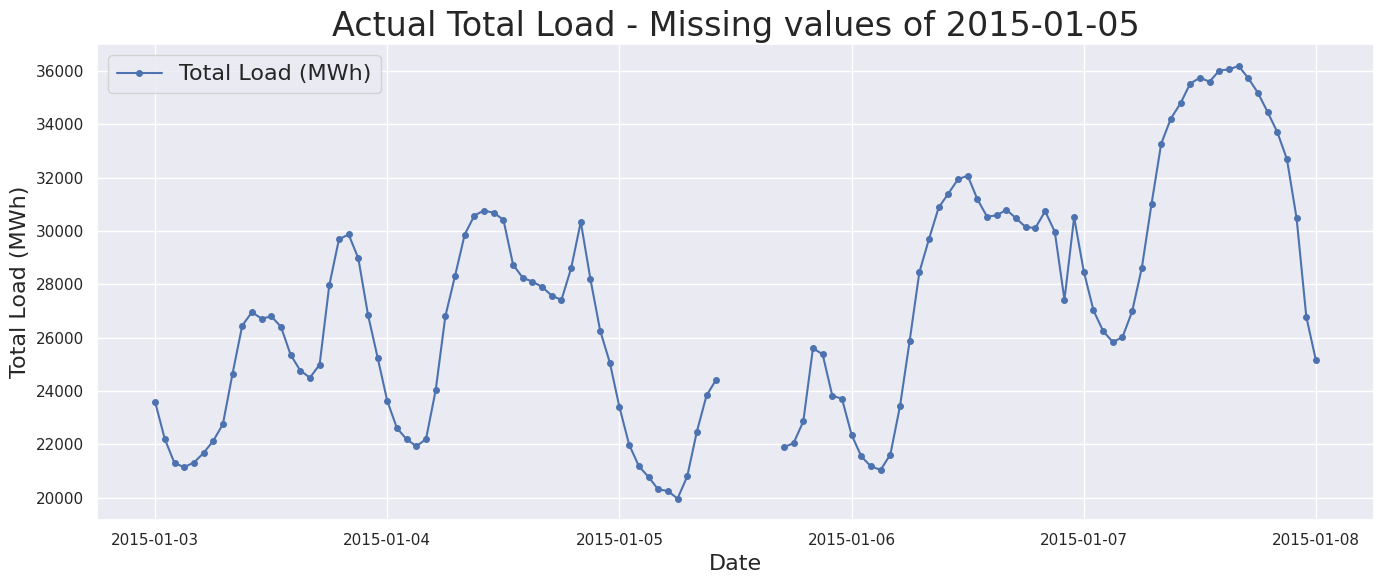

In [159]:
# Missing values of 2015-01-05
plot_series(
    df=df_energy,
    columns='total load actual',
    start='2015-01-03 00:00:00+00:00',
    end='2015-01-08 00:00:00+00:00',
    label='Total Load (MWh)',
    ylabel='Total Load (MWh)',
    title='Actual Total Load - Missing values of 2015-01-05'
)

<Axes: title={'center': 'Actual Total Load - Missing values of 2015-02-01'}, xlabel='Date', ylabel='Total Load (MWh)'>

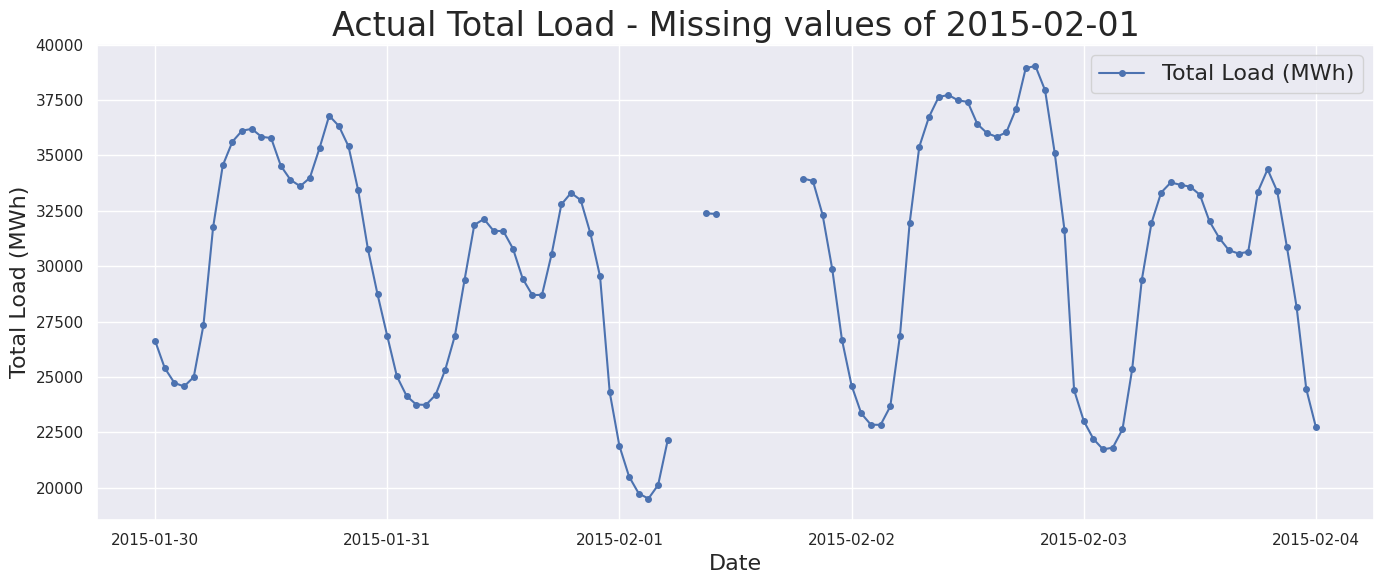

In [160]:
# Missing values of 2015-02-01
plot_series(
    df=df_energy,
    columns='total load actual',
    start='2015-01-30 00:00:00+00:00',
    end='2015-02-04 00:00:00+00:00',
    label='Total Load (MWh)',
    ylabel='Total Load (MWh)',
    title='Actual Total Load - Missing values of 2015-02-01'
)

In order to replicate those curvy patterns we will try different interplotation methods.

In [161]:
df_energy['total load actual linear'] = df_energy['total load actual'].interpolate(method='linear')
df_energy['total load actual quadratic'] = df_energy['total load actual'].interpolate(method='quadratic')
df_energy['total load actual cubic'] = df_energy['total load actual'].interpolate(method='cubic')

<Axes: title={'center': 'Actual Total Load - Missing values of 2015-01-05'}, xlabel='Date', ylabel='Total Load (MWh)'>

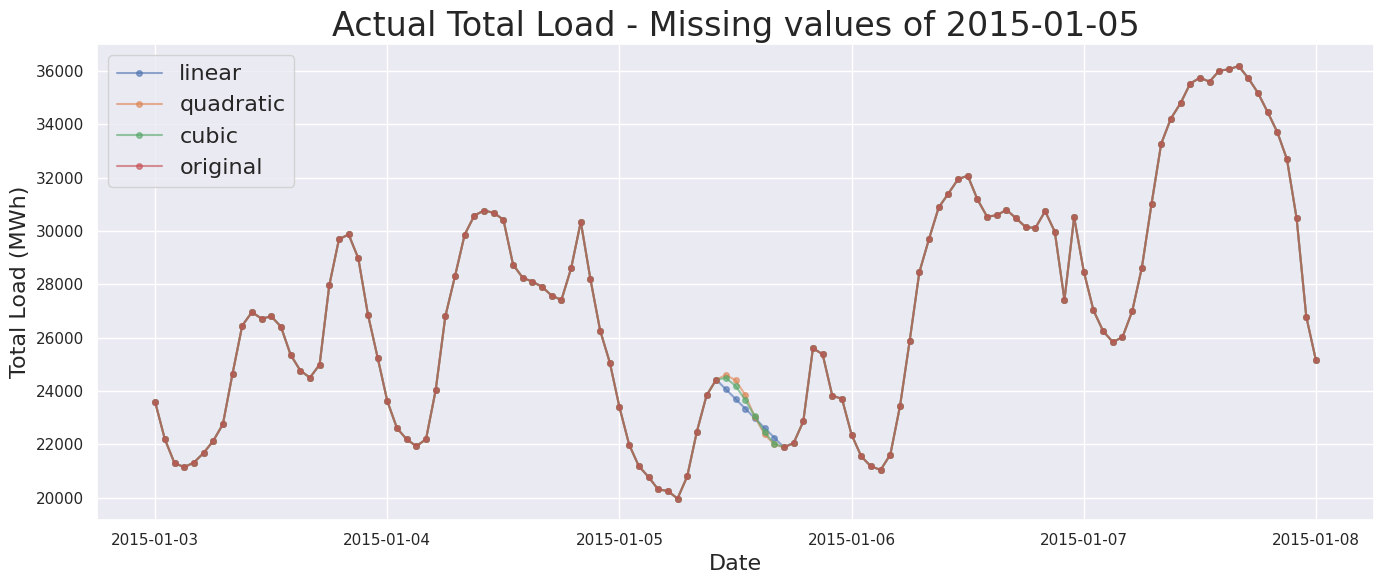

In [162]:
plot_series(
    df=df_energy,
    columns=[
        'total load actual linear',
        'total load actual quadratic',
        'total load actual cubic',
        'total load actual',
    ],
    start='2015-01-03 00:00:00+00:00',
    end='2015-01-08 00:00:00+00:00',
    label=[
        'linear',
        'quadratic',
        'cubic',
        'original',
    ],
    ylabel='Total Load (MWh)',
    title='Actual Total Load - Missing values of 2015-01-05'
)

<Axes: title={'center': 'Actual Total Load - Missing values of 2015-02-01'}, xlabel='Date', ylabel='Total Load (MWh)'>

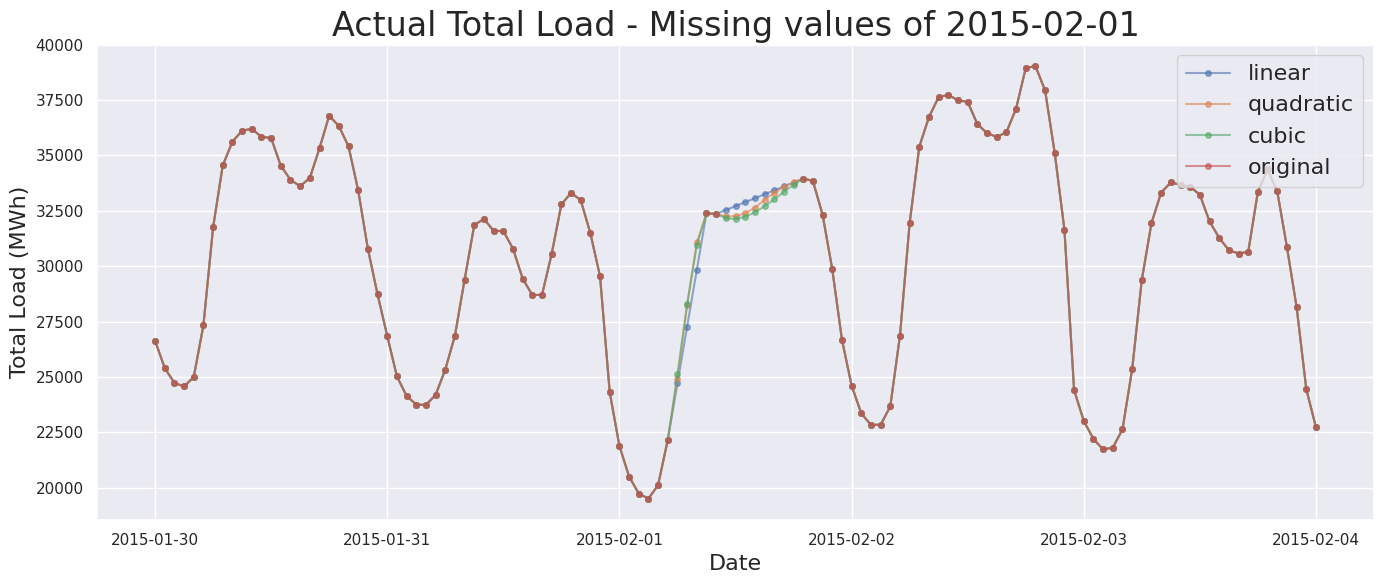

In [163]:
plot_series(
    df=df_energy,
    columns=[
        'total load actual linear',
        'total load actual quadratic',
        'total load actual cubic',
        'total load actual',
    ],
    start='2015-01-30 00:00:00+00:00',
    end='2015-02-04 00:00:00+00:00',
    label=[
        'linear',
        'quadratic',
        'cubic',
        'original',
    ],
    ylabel='Total Load (MWh)',
    title='Actual Total Load - Missing values of 2015-02-01'
)

The best interpolation method seems to be the cuadratic one, so we will use that and remove the others.

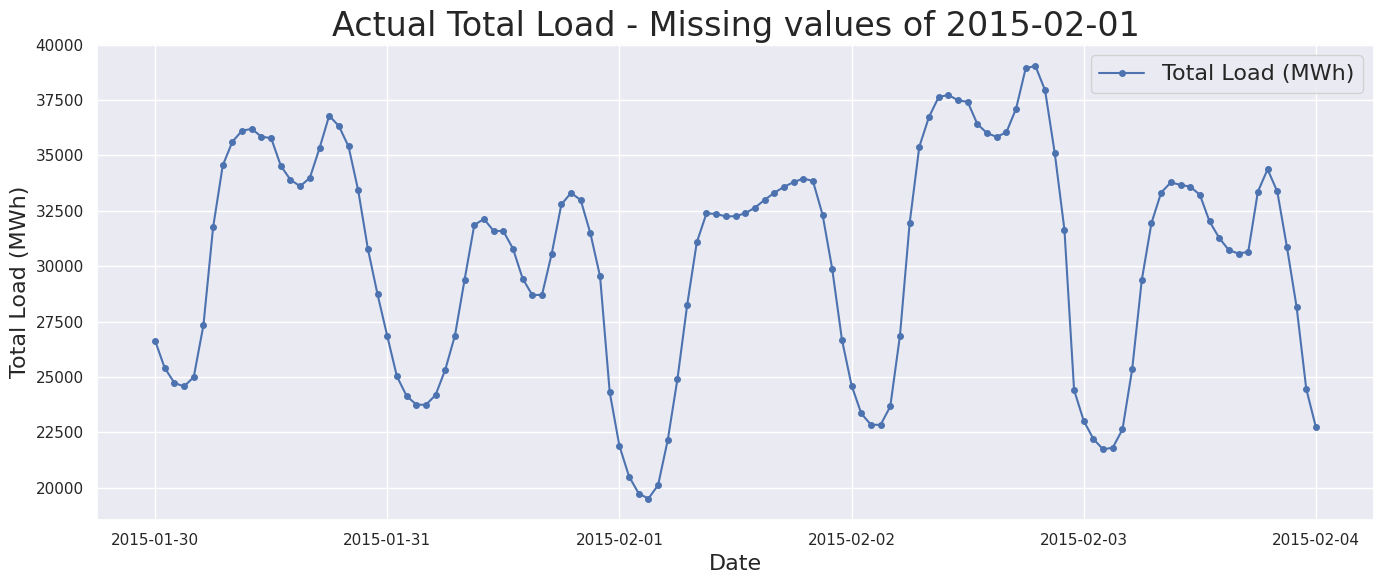

In [164]:
df_energy['total load actual'] = df_energy['total load actual'].interpolate(method='quadratic')
plot_series(
    df=df_energy,
    columns='total load actual',
    start='2015-01-30 00:00:00+00:00',
    end='2015-02-04 00:00:00+00:00',
    label='Total Load (MWh)',
    ylabel='Total Load (MWh)',
    title='Actual Total Load - Missing values of 2015-02-01'
)
df_energy = df_energy.drop([
    'total load actual linear',
    'total load actual quadratic',
    'total load actual cubic'
], axis=1)

#### Rest of variables

In [165]:
# Find the number of NaNs in each column
df_energy.isnull().sum(axis=0)

generation biomass                             23
generation fossil brown coal/lignite           21
generation fossil gas                          19
generation fossil hard coal                    21
generation fossil oil                          22
generation hydro pumped storage consumption    23
generation hydro run-of-river and poundage     22
generation hydro water reservoir               21
generation nuclear                             20
generation other                               22
generation other renewable                     21
generation solar                               21
generation waste                               22
generation wind onshore                        21
total load forecast                             0
total load actual                               0
dtype: int64

In [166]:
df_energy[df_energy['generation biomass'].isnull()]['generation biomass']

time
2015-01-05 02:00:00+00:00   NaN
2015-01-05 11:00:00+00:00   NaN
2015-01-05 12:00:00+00:00   NaN
2015-01-05 13:00:00+00:00   NaN
2015-01-05 14:00:00+00:00   NaN
2015-01-05 15:00:00+00:00   NaN
2015-01-05 16:00:00+00:00   NaN
2015-01-19 18:00:00+00:00   NaN
2015-01-19 19:00:00+00:00   NaN
2015-01-27 18:00:00+00:00   NaN
2015-01-28 12:00:00+00:00   NaN
2015-04-16 07:00:00+00:00   NaN
2015-04-23 19:00:00+00:00   NaN
2015-06-15 07:00:00+00:00   NaN
2015-10-02 09:00:00+00:00   NaN
2015-12-02 08:00:00+00:00   NaN
2016-07-09 20:00:00+00:00   NaN
2016-11-23 03:00:00+00:00   NaN
2017-11-12 20:00:00+00:00   NaN
2017-11-14 11:00:00+00:00   NaN
2017-11-14 18:00:00+00:00   NaN
2018-05-06 10:00:00+00:00   NaN
2018-07-11 07:00:00+00:00   NaN
Name: generation biomass, dtype: float64

<Axes: title={'center': 'Generation Biomass - Missing values of 2015-01-05'}, xlabel='Date', ylabel='Generation Biomass'>

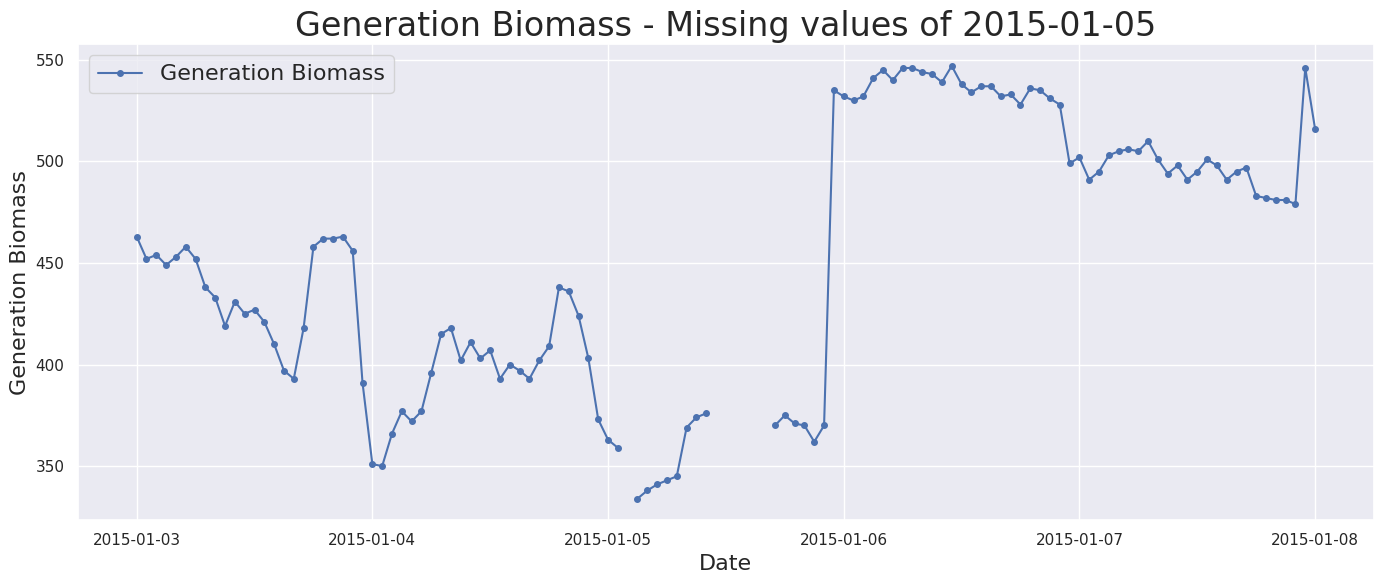

In [167]:
# Missing values of 2015-01-05
plot_series(
    df=df_energy,
    columns='generation biomass',
    start='2015-01-03 00:00:00+00:00',
    end='2015-01-08 00:00:00+00:00',
    label='Generation Biomass',
    ylabel='Generation Biomass',
    title='Generation Biomass - Missing values of 2015-01-05'
)

In [168]:
df_energy[df_energy['generation fossil brown coal/lignite'].isnull()]['generation fossil brown coal/lignite']

time
2015-01-05 02:00:00+00:00   NaN
2015-01-05 11:00:00+00:00   NaN
2015-01-05 12:00:00+00:00   NaN
2015-01-05 13:00:00+00:00   NaN
2015-01-05 14:00:00+00:00   NaN
2015-01-05 15:00:00+00:00   NaN
2015-01-05 16:00:00+00:00   NaN
2015-01-19 18:00:00+00:00   NaN
2015-01-19 19:00:00+00:00   NaN
2015-01-27 18:00:00+00:00   NaN
2015-01-28 12:00:00+00:00   NaN
2015-04-16 07:00:00+00:00   NaN
2015-04-23 19:00:00+00:00   NaN
2015-06-15 07:00:00+00:00   NaN
2015-10-02 09:00:00+00:00   NaN
2015-12-02 08:00:00+00:00   NaN
2016-07-09 20:00:00+00:00   NaN
2017-11-12 20:00:00+00:00   NaN
2017-11-14 11:00:00+00:00   NaN
2017-11-14 18:00:00+00:00   NaN
2018-07-11 07:00:00+00:00   NaN
Name: generation fossil brown coal/lignite, dtype: float64

<Axes: title={'center': 'Generation Fossil Brown Coal/Lignite - Missing values of 2015-01-05'}, xlabel='Date', ylabel='Generation Fossil Brown Coal/Lignite'>

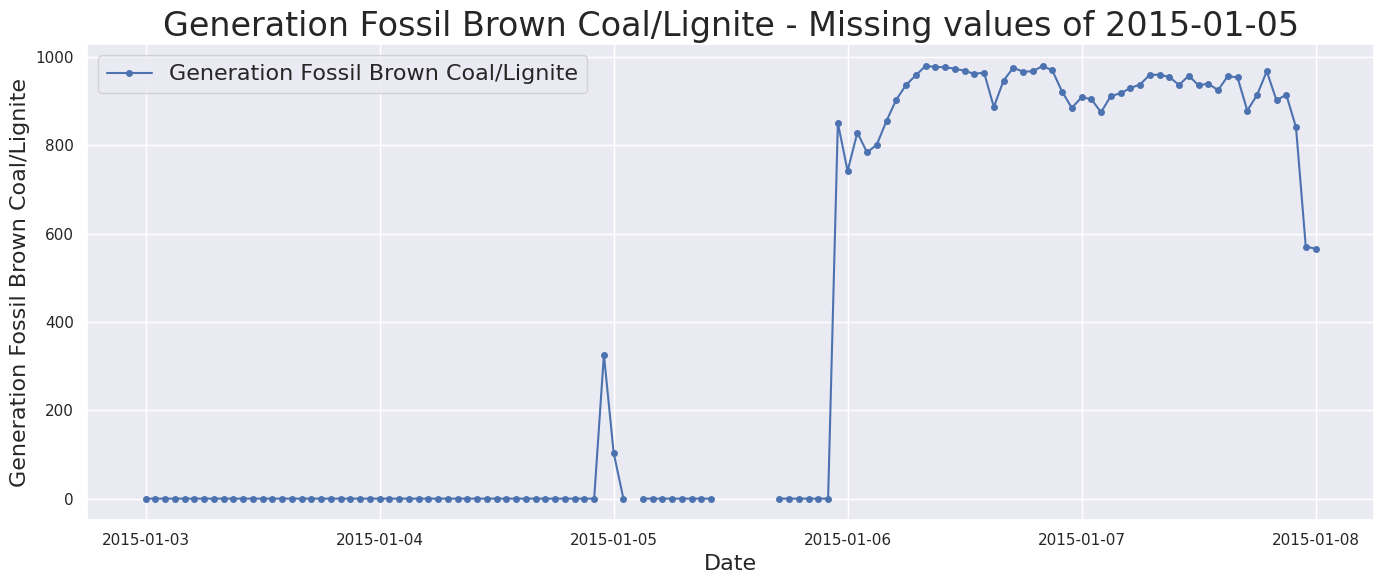

In [169]:
# Missing values of 2015-01-05
plot_series(
    df=df_energy,
    columns='generation fossil brown coal/lignite',
    start='2015-01-03 00:00:00+00:00',
    end='2015-01-08 00:00:00+00:00',
    label='Generation Fossil Brown Coal/Lignite',
    ylabel='Generation Fossil Brown Coal/Lignite',
    title='Generation Fossil Brown Coal/Lignite - Missing values of 2015-01-05'
)

It seems that most of the variables have missing values on the same period of 2015-01-05. Let's check that.

In [170]:
for column in df_energy.columns:
    if df_energy[column].isnull().sum():
        print('='*60)
        print(column)
        print(df_energy[df_energy[column].isnull()][column])
        print('='*60)
        print()

generation biomass
time
2015-01-05 02:00:00+00:00   NaN
2015-01-05 11:00:00+00:00   NaN
2015-01-05 12:00:00+00:00   NaN
2015-01-05 13:00:00+00:00   NaN
2015-01-05 14:00:00+00:00   NaN
2015-01-05 15:00:00+00:00   NaN
2015-01-05 16:00:00+00:00   NaN
2015-01-19 18:00:00+00:00   NaN
2015-01-19 19:00:00+00:00   NaN
2015-01-27 18:00:00+00:00   NaN
2015-01-28 12:00:00+00:00   NaN
2015-04-16 07:00:00+00:00   NaN
2015-04-23 19:00:00+00:00   NaN
2015-06-15 07:00:00+00:00   NaN
2015-10-02 09:00:00+00:00   NaN
2015-12-02 08:00:00+00:00   NaN
2016-07-09 20:00:00+00:00   NaN
2016-11-23 03:00:00+00:00   NaN
2017-11-12 20:00:00+00:00   NaN
2017-11-14 11:00:00+00:00   NaN
2017-11-14 18:00:00+00:00   NaN
2018-05-06 10:00:00+00:00   NaN
2018-07-11 07:00:00+00:00   NaN
Name: generation biomass, dtype: float64

generation fossil brown coal/lignite
time
2015-01-05 02:00:00+00:00   NaN
2015-01-05 11:00:00+00:00   NaN
2015-01-05 12:00:00+00:00   NaN
2015-01-05 13:00:00+00:00   NaN
2015-01-05 14:00:00+00:00   

Most of the time stamps of the missing values coincide between variables. As there are only a few missing values, instead of studing each variable, we will apply a linear interpolation to all of them. The noise introduced by doing this should be low.

In [171]:
df_energy.interpolate(method='linear', inplace=True, axis=0)

In [172]:
# Find the number of NaNs in each column
df_energy.isnull().sum(axis=0)

generation biomass                             0
generation fossil brown coal/lignite           0
generation fossil gas                          0
generation fossil hard coal                    0
generation fossil oil                          0
generation hydro pumped storage consumption    0
generation hydro run-of-river and poundage     0
generation hydro water reservoir               0
generation nuclear                             0
generation other                               0
generation other renewable                     0
generation solar                               0
generation waste                               0
generation wind onshore                        0
total load forecast                            0
total load actual                              0
dtype: int64

### 1.1.3 Saving dataframes
Finally, we will separate target variables (TSO forecast and total actual load) and save the three dataframes as CSV in an ordered way.

In [173]:
df_TSO_forecast = df_energy['total load forecast'].copy()
df_energy_target = df_energy['total load actual'].copy()
df_energy = df_energy.drop([
    'total load forecast',
    'total load actual'
], axis=1)

In [174]:
df_TSO_forecast.describe().round(2)

count    35064.00
mean     28712.13
std       4594.10
min      18105.00
25%      24793.75
50%      28906.00
75%      32263.25
max      41390.00
Name: total load forecast, dtype: float64

In [175]:
df_energy_target.describe().round(2)

count    35064.00
mean     28698.46
std       4576.01
min      18041.00
25%      24807.75
50%      28902.00
75%      32194.25
max      41015.00
Name: total load actual, dtype: float64

In [176]:
df_energy.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,383.57,448.17,5622.90,4257.09,298.37,475.59,972.27,2605.66,6263.97,60.23,85.64,1432.95,269.44,5465.60
std,85.25,354.62,2201.32,1961.71,52.45,792.31,400.63,1835.07,838.33,20.23,14.06,1680.00,50.16,3213.25
min,101.00,0.00,1518.00,576.00,44.00,0.00,283.00,134.00,998.00,3.00,4.00,2.00,39.00,234.00
25%,333.00,0.00,4126.00,2527.75,263.00,0.00,637.00,1078.00,5759.75,53.00,73.00,71.00,240.00,2933.75
50%,367.00,509.00,4970.00,4475.00,300.00,68.00,906.00,2165.00,6564.50,57.00,88.00,616.00,279.00,4850.00
75%,433.00,757.00,6429.00,5840.00,330.00,616.00,1250.00,3758.00,7025.00,80.00,97.00,2579.00,310.00,7401.00
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00


In [177]:
df_TSO_forecast.to_csv('../data/interim/TSO_forecast.csv')
df_energy_target.to_csv('../data/interim/energy_dataset_target.csv')
df_energy.to_csv('../data/interim/energy_dataset.csv')

## 1.2 Exogenous variables
This dataset is generated from 02_EXOG.ipynb notebook

In [191]:
import json

exog_df = pd.read_csv('../data/interim/exogs_df.csv', index_col=0, parse_dates=True)

with open('../data/interim/exog_columns.json', 'r') as f:
    exog_columns = json.load(f)

In [192]:
exog_df.head()

,eurusd_close_lag1,ttf_gas_eur_lag1,brent_close_eur_lag1,is_top_liga_match,is_national_team_match,is_national_holiday,barcelona_temp,bilbao_temp,madrid_temp,seville_temp,...,barcelona_weather_good,bilbao_weather_good,madrid_weather_good,seville_weather_good,valencia_weather_good,barcelona_weather_mid,bilbao_weather_mid,madrid_weather_mid,seville_weather_mid,valencia_weather_mid
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,1.216205,21.296,47.138445,0,0,0,8.475,-3.492687,-5.825,0.225,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,1.216205,21.296,47.138445,0,0,1,8.475,-3.386500,-5.825,0.225,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,1.216205,21.296,47.138445,0,0,1,8.136,-3.898312,-6.964,0.936,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00+00:00,1.216205,21.296,47.138445,0,0,1,8.136,-3.946656,-6.964,0.936,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00+00:00,1.216205,21.296,47.138445,0,0,1,8.136,-3.664500,-6.964,0.936,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


## 1.3 Merging dataframes

In [193]:
whole_df = df_energy_target.to_frame().join(df_energy)
whole_df = whole_df.join(exog_df)
whole_df.head()

,total load actual,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,barcelona_weather_good,bilbao_weather_good,madrid_weather_good,seville_weather_good,valencia_weather_good,barcelona_weather_mid,bilbao_weather_mid,madrid_weather_mid,seville_weather_mid,valencia_weather_mid
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,25385.0,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,24382.0,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,22734.0,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00+00:00,21286.0,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00+00:00,20264.0,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# 2. Decomposition and stationarity tests

First 4 weeks - Additive model


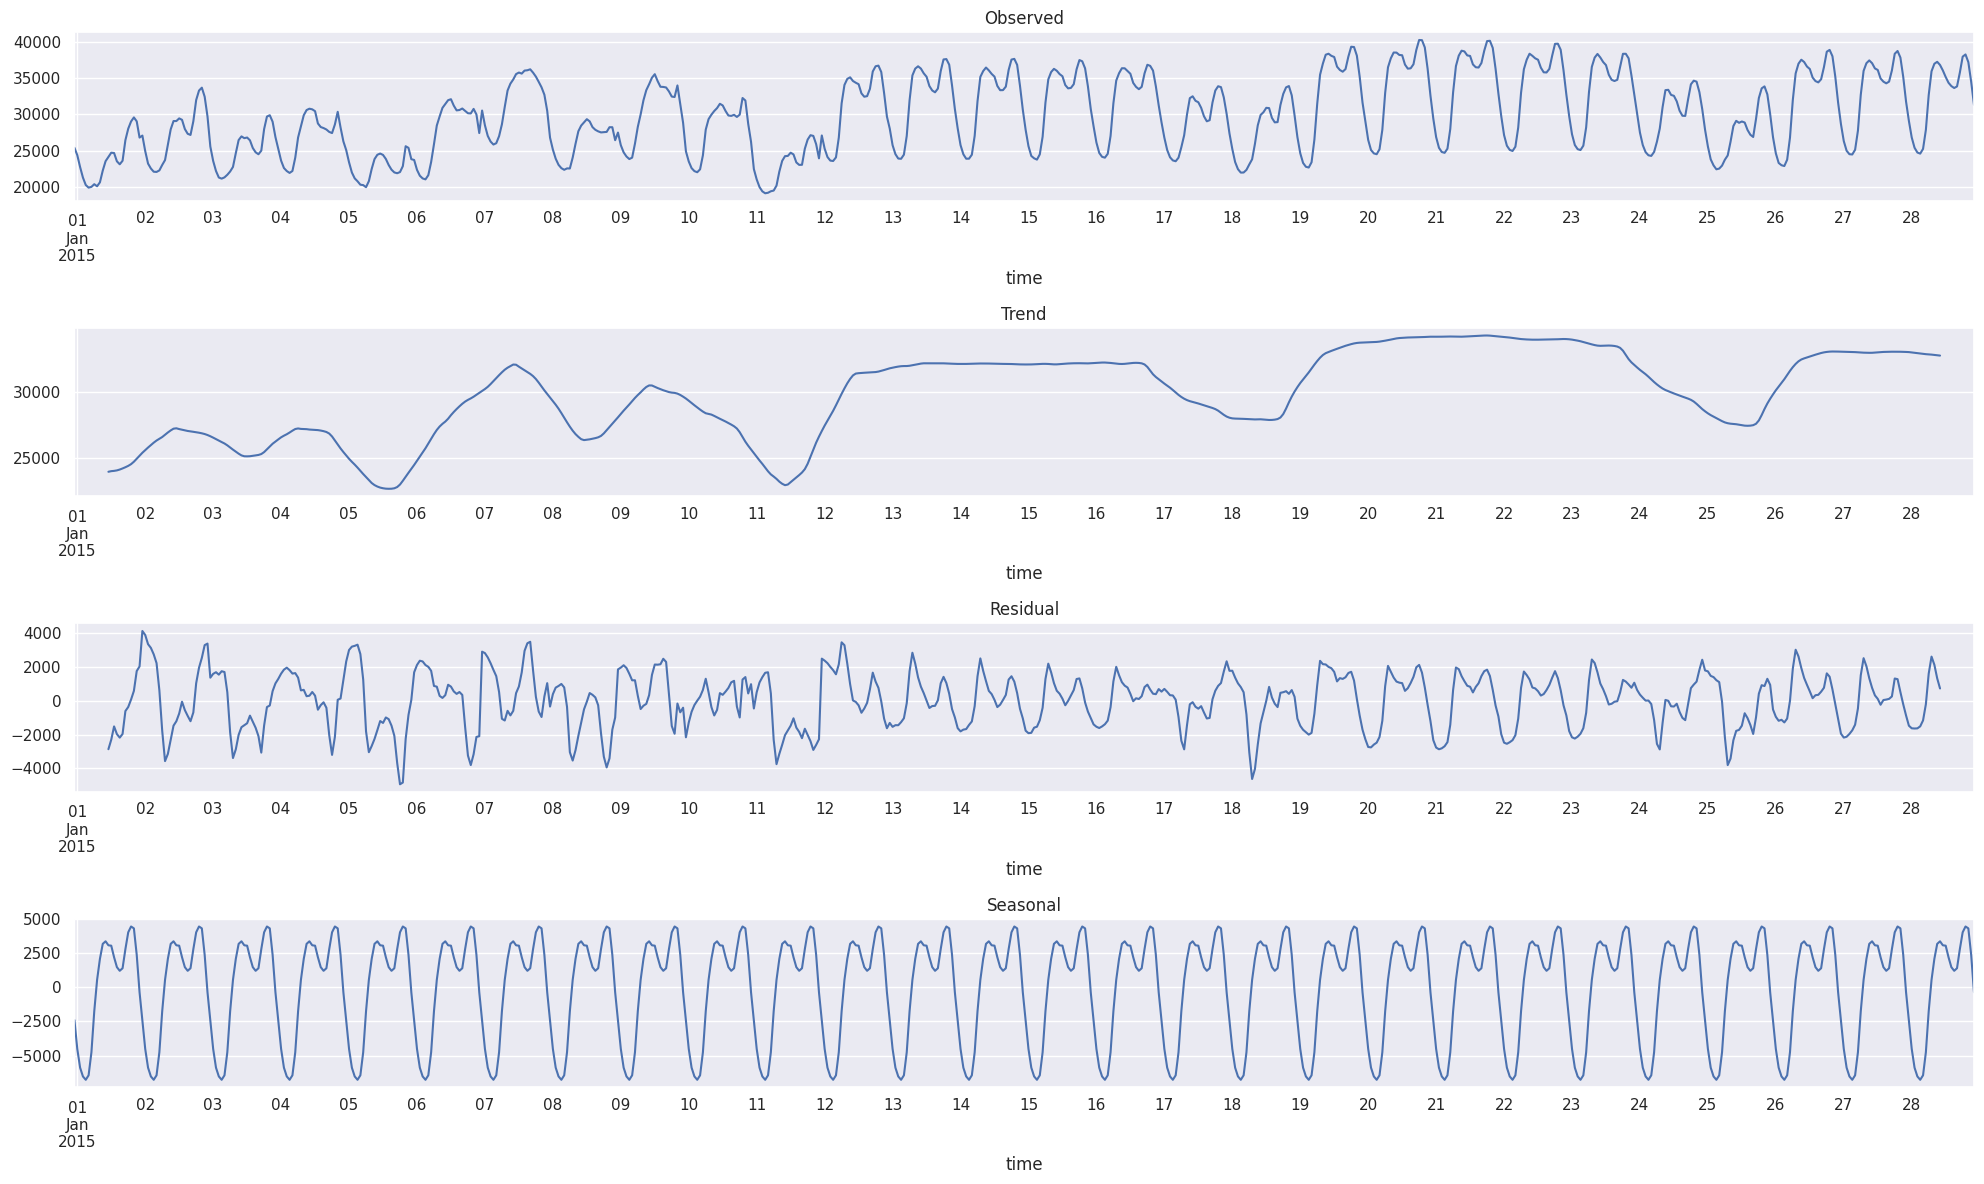

In [208]:
print('First 4 weeks - Additive model')
res = sm.tsa.seasonal_decompose(whole_df['total load actual'].iloc[:24*7*4], model='additive')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

First 4 weeks - Multiplicative model


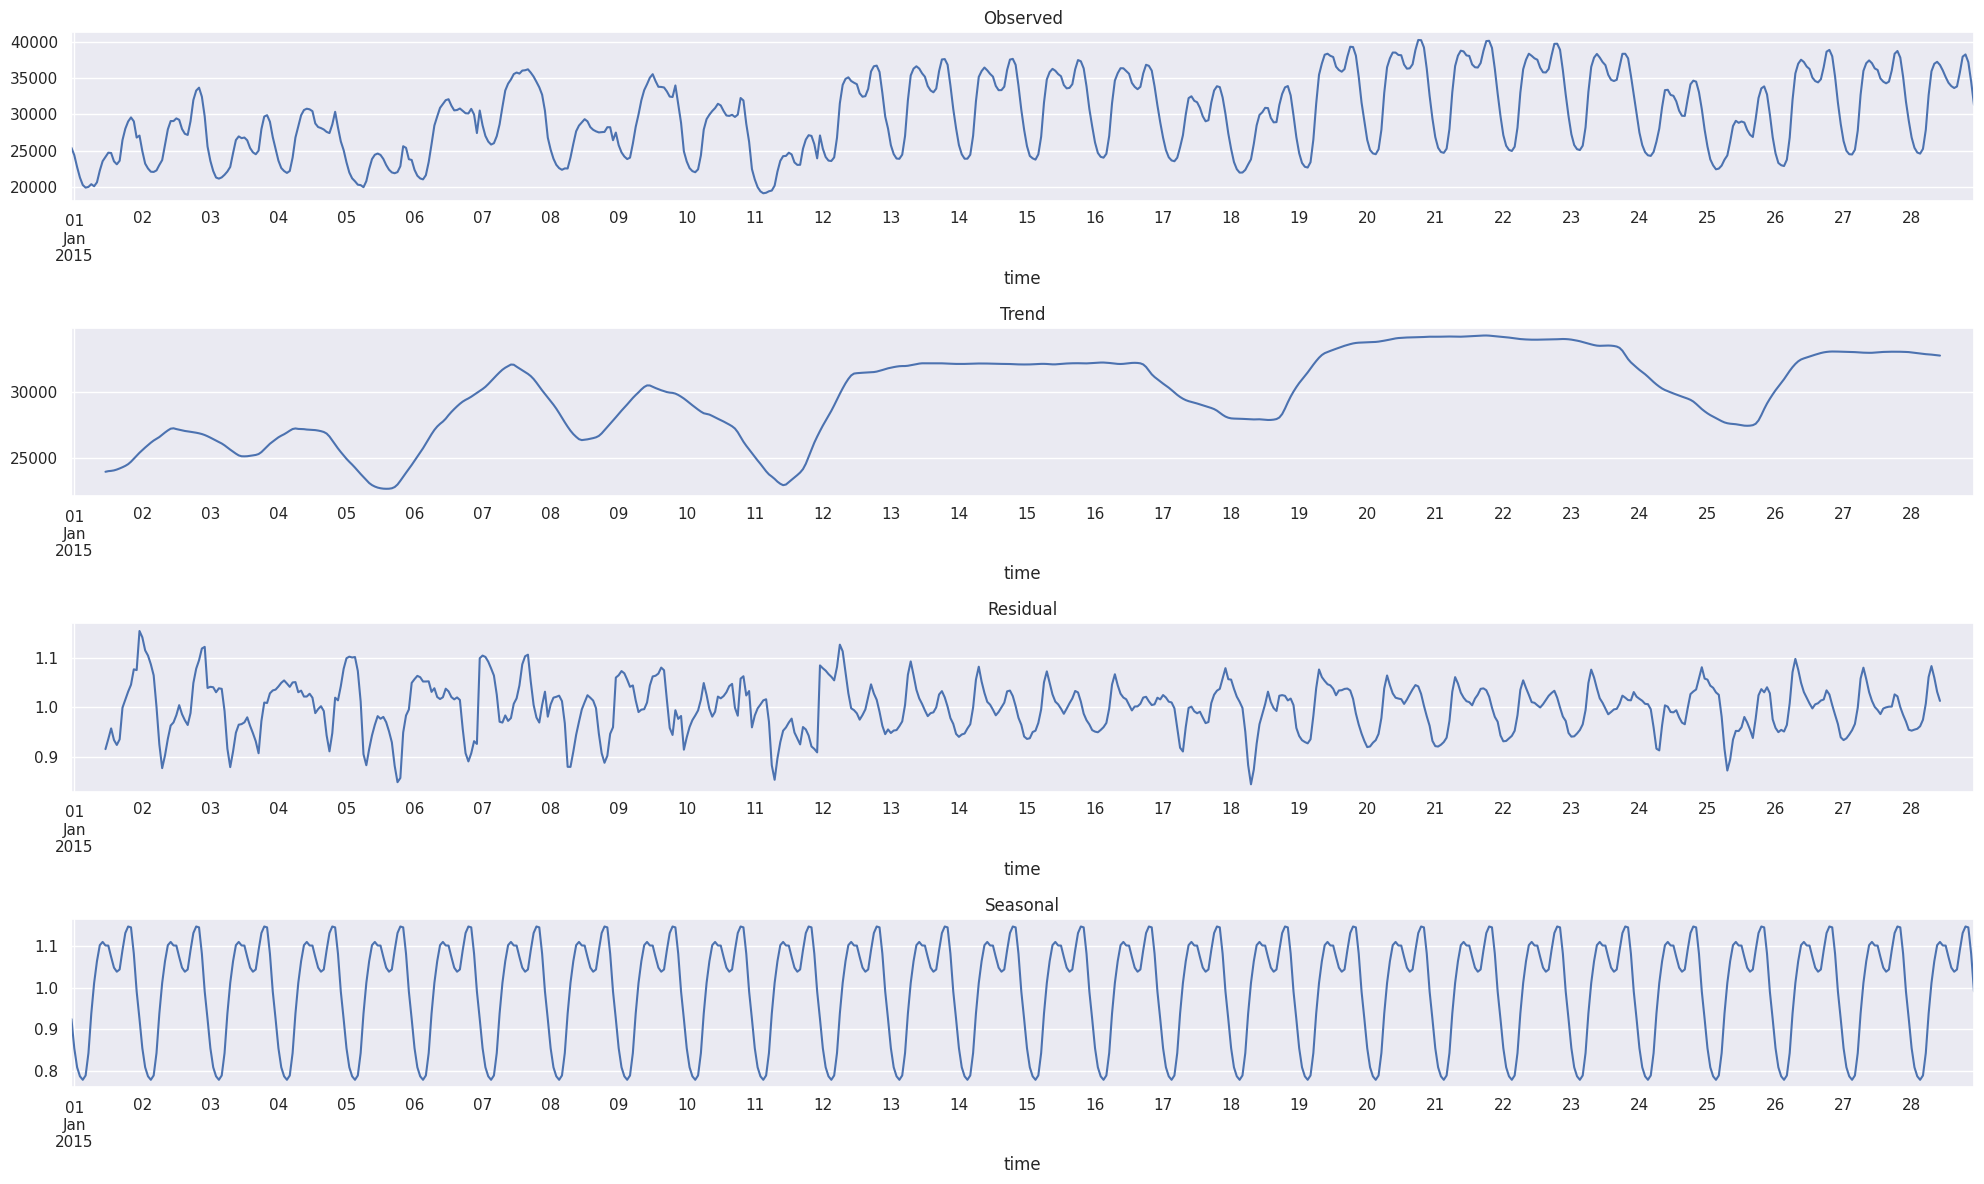

In [209]:
print('First 4 weeks - Multiplicative model')
res = sm.tsa.seasonal_decompose(whole_df['total load actual'].iloc[:24*7*4], model='multiplicative')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

Last 4 weeks - Additive model


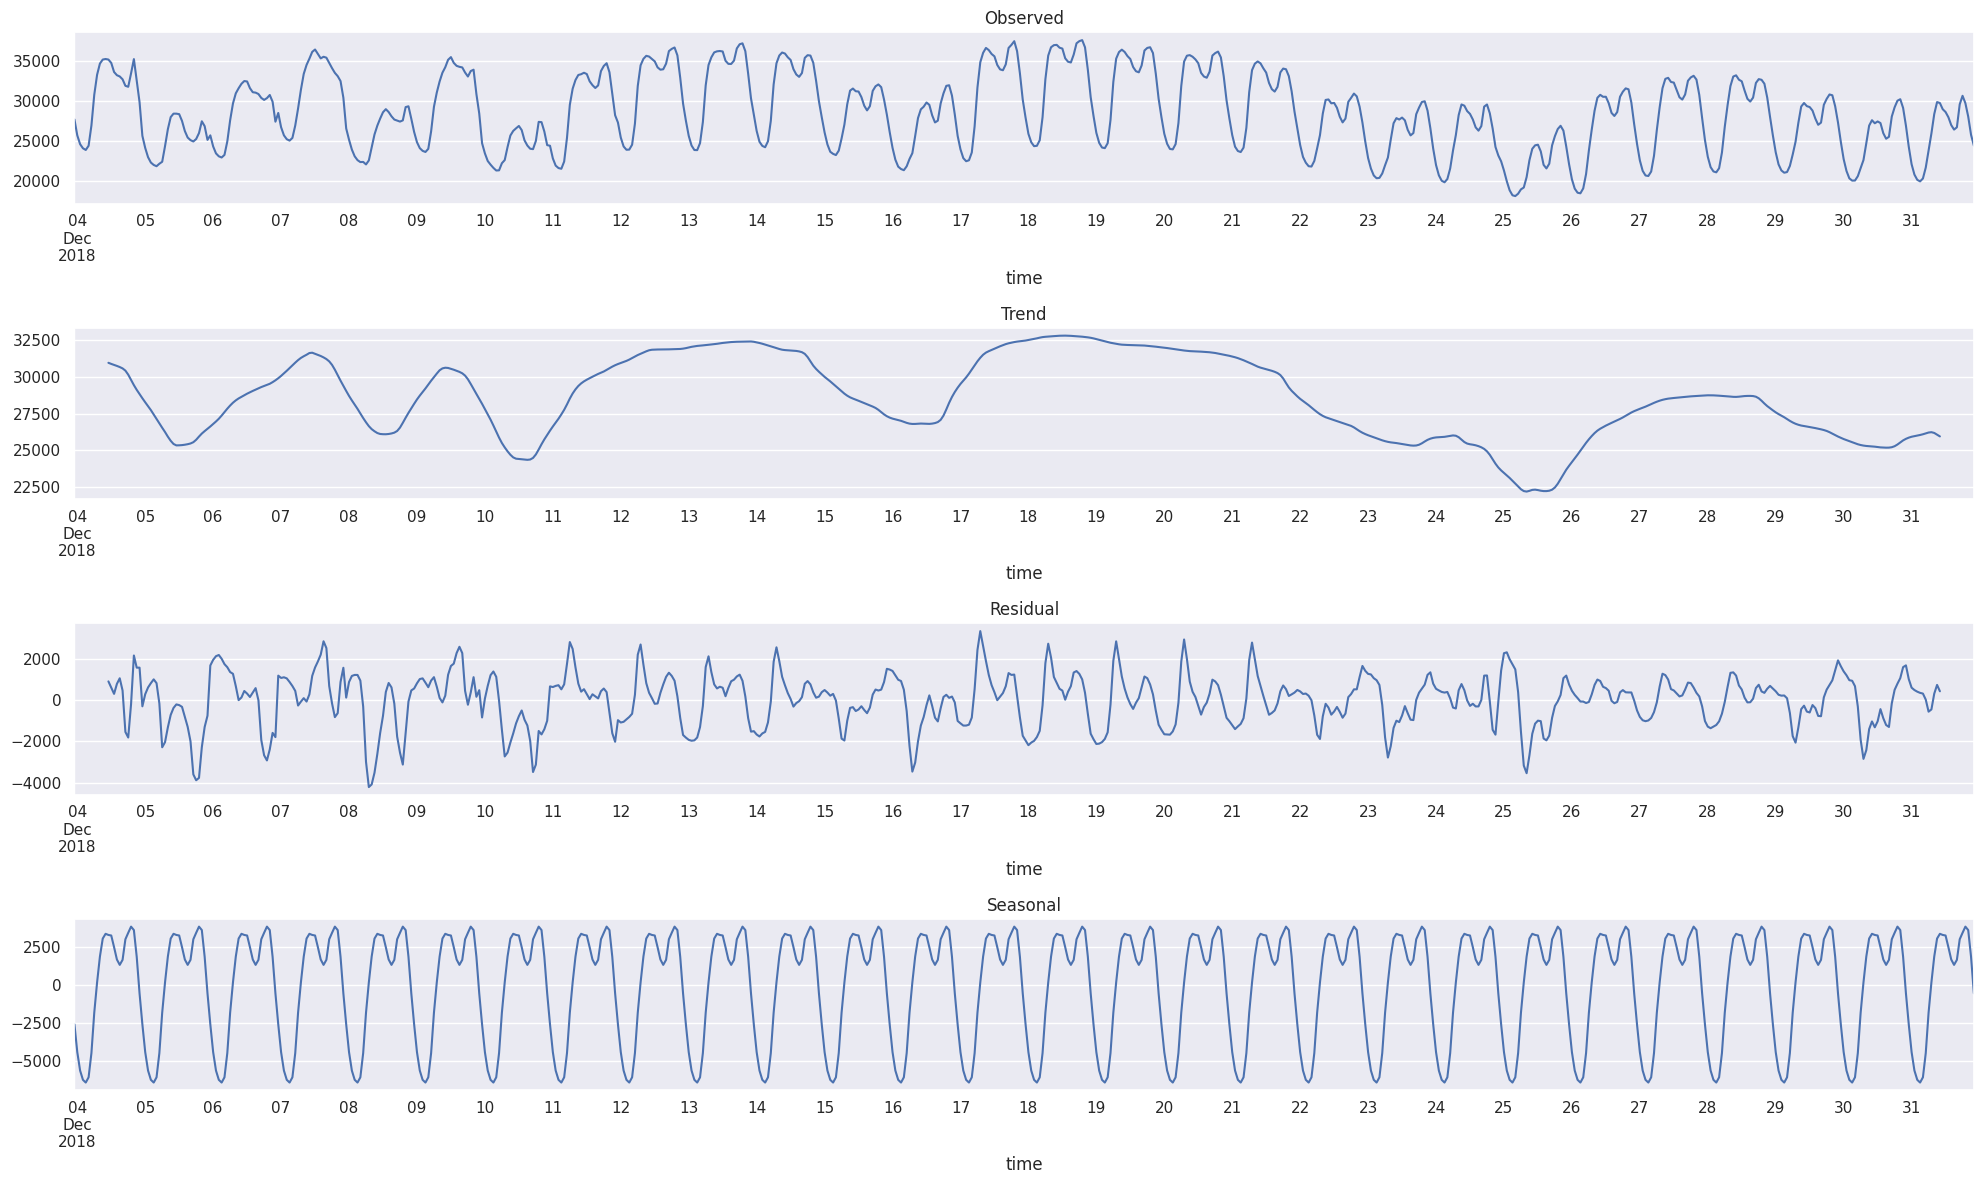

In [211]:
print('Last 4 weeks - Additive model')
res = sm.tsa.seasonal_decompose(whole_df['total load actual'].iloc[-24*7*4:], model='additive')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

Last 4 weeks - Multiplicative model


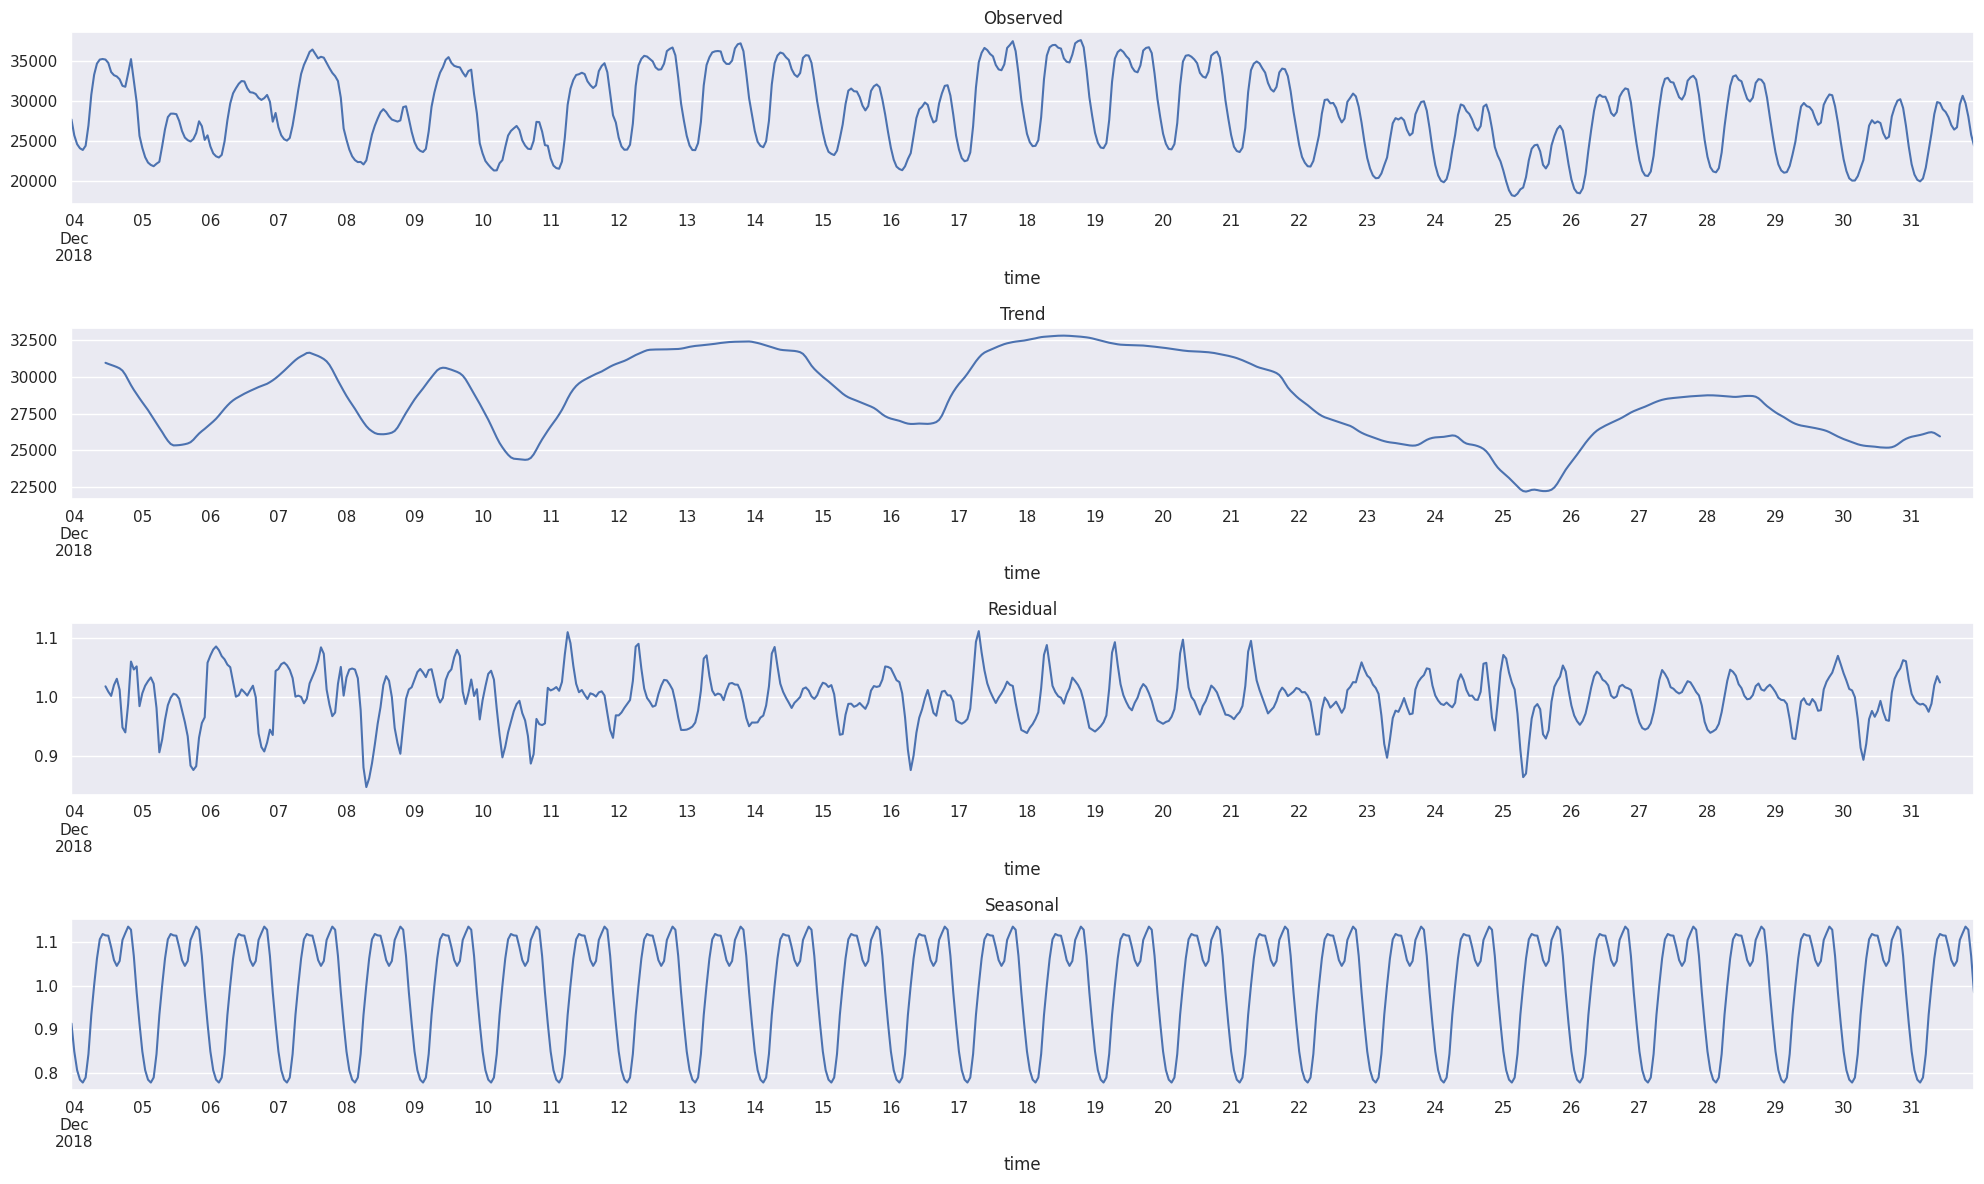

In [212]:
print('Last 4 weeks - Multiplicative model')
res = sm.tsa.seasonal_decompose(whole_df['total load actual'].iloc[-24*7*4:], model='multiplicative')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

## <a id='ref14'>2.3. Autocorrelation, partial autocorrelation and cross-correlation</a> 

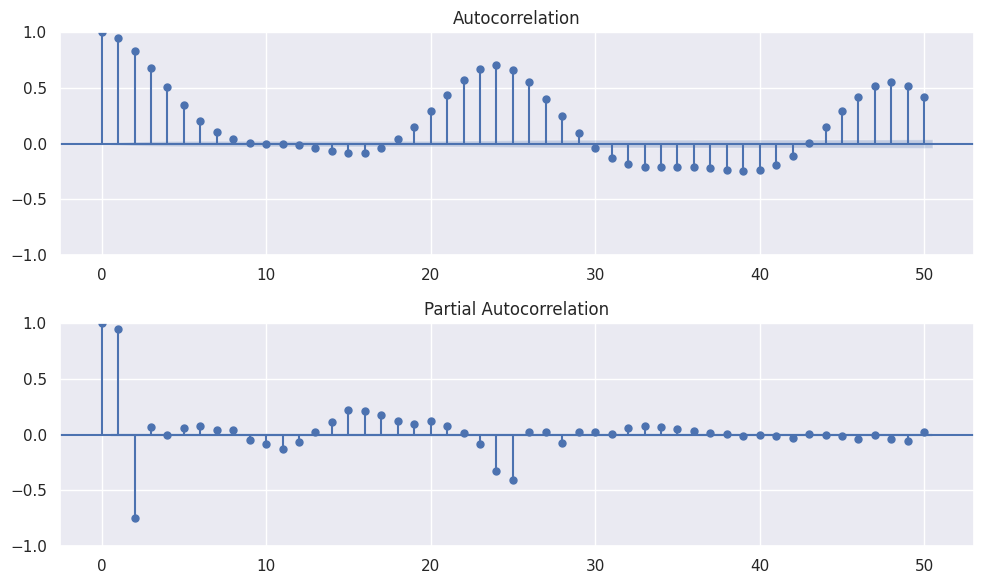

In [215]:
# Plot autocorrelation and partial autocorrelation plots
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 6))
plot_acf(whole_df['total load actual'], lags=50, ax=ax1)
plot_pacf(whole_df['total load actual'], lags=50, ax=ax2)
plt.tight_layout()
plt.show()

## Autocorrelation and Partial Autocorrelation Analysis

### ACF (Autocorrelation)
- **Lags 1–3**: Very high and gradually decreasing correlation, indicating a strong dependency on the immediately preceding hours.
- **Spike at lag ~24**: High correlation confirming a clear **daily cycle** — the load from 24 hours ago is highly predictive of the current value.
- **Spike at lag ~48**: The daily cycle repeats, albeit with lower intensity.
- Correlation **does not decay quickly to zero**, suggesting the series is **non-stationary** or exhibits strong trend/seasonality.

### PACF (Partial Autocorrelation)
- **Lag 1**: Very high partial correlation (~0.95), the single most important lag.
- **Lag 2**: Strong negative correlation (~-0.7), a correction effect following lag 1.
- **Lags 3+**: Essentially zero, except for a notable spike around lags 24–25.
- This indicates that, **once the effect of lag 1 is controlled for**, the remaining short-term lags contribute little additional information.

### Modelling Implications
- The most relevant lags to include as features are: **lag 1, lag 2, lag 24**, and possibly **lag 48**.
- The daily seasonality is very pronounced → **calendar variables** (hour of day, day of week) should be included.
- For ARIMA-based models, the PACF pattern suggests an **AR(1) or AR(2)** process with a seasonal component at period 24.

In [216]:
correlations = whole_df.corr(method='pearson')
print(correlations['total load actual'].sort_values(ascending=False).to_string())

total load actual                              1.000000
generation fossil gas                          0.549233
generation fossil oil                          0.497629
generation hydro water reservoir               0.479619
generation fossil hard coal                    0.397574
generation solar                               0.395550
generation fossil brown coal/lignite           0.281037
valencia_temp_min                              0.235106
valencia_temp                                  0.220360
seville_temp_min                               0.205797
madrid_temp_max                                0.204277
seville_temp                                   0.203589
valencia_wind_y                                0.199088
valencia_temp_max                              0.199084
bilbao_temp                                    0.196005
bilbao_temp_min                                0.193458
bilbao_temp_max                                0.193440
barcelona_temp_min                             0

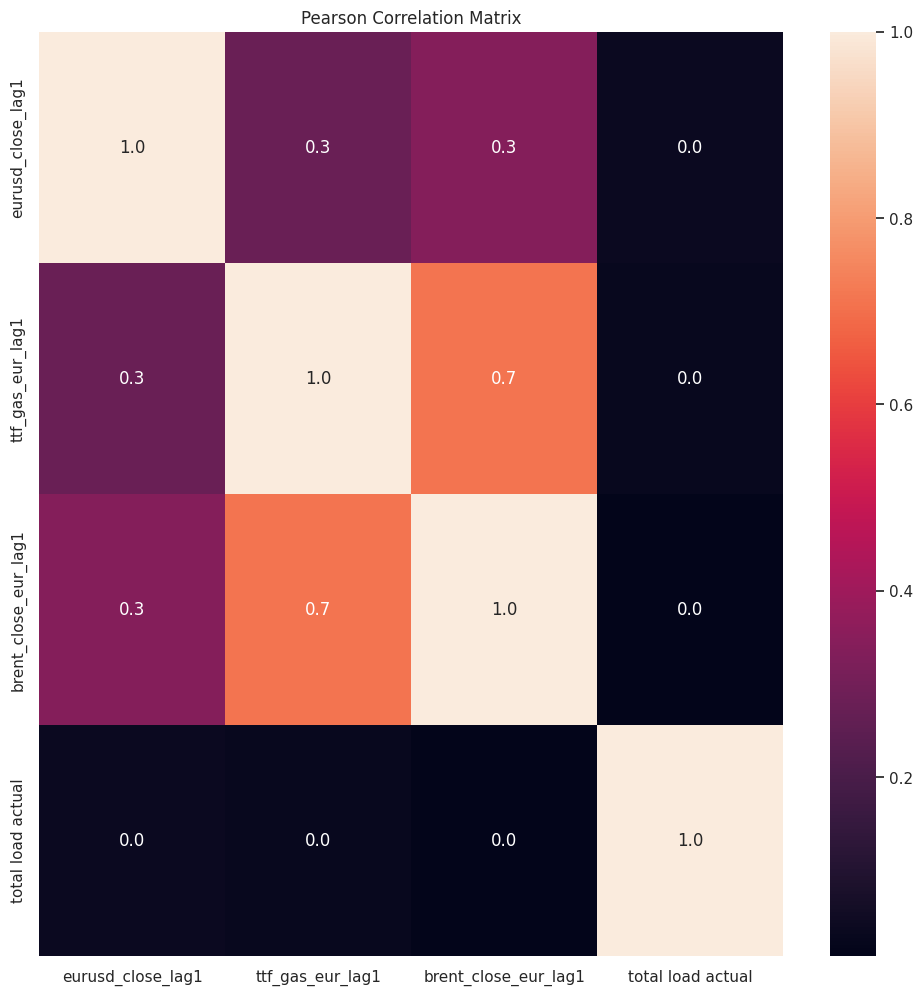

In [230]:
correlations = whole_df[exog_columns['Economics'] + ['total load actual']].corr(method='pearson')
fig = plt.figure(figsize=(12, 12))
sns.heatmap(correlations, annot=True, fmt='.1f')
plt.title('Pearson Correlation Matrix')
plt.savefig('../report/figures/corr_matrix.pdf', dpi=300)
plt.show()